## HW3: Agentic Workflow RAG Tool

### OA4910, Winter Quarter AY2026

### Situation

Continuing from HW2, you are building a player's assistant for your weekly Dungeons and Dragons (D&D) game. Participants have learned more about how to play D&D but are looking for advice to help them play better.

### Instructions

You are provided with coded components of an agentic workflow RAG assistant -- some components are complete and ready for implementation, some will need completion or modification, and others you'll have to build from scratch. Code blocks have comments that indicate their level of completion: <span style="color: green;">GREEN</span> indicates complete and ready to run, <span style="color: yellow;">YELLOW</span> indicates some additions or modifications are required, and <span style="color: red;">RED</span> indicates a near empty cell that you must build. Some general comments have been provided but you should add comments for any code that you add.

Specified Tasks:
  * Piece together the provided components to have a complete RAG Agentic Workflow that is able to accept a prompt and terminate with a response provided. 
  * Build and utilize a vector database given a corpus of documents.
  * Implement the provided tools: `Router`, `DuckDuckGoSearch`.
  * Build and implement your own tool that mimics a dice being rolled with a python function.

Constraints:
 * You may only use LLMs hosted by TDAC.

Submission **(two files)**: <br>
1) An `ipynb` file saved as `hw3_workflow_LastName.ipynb` with all cell outputs visible. <br>
2) The same notebook as above, saved as a `.md` file.

Below is a logic diagram providing how the tool should be setup.


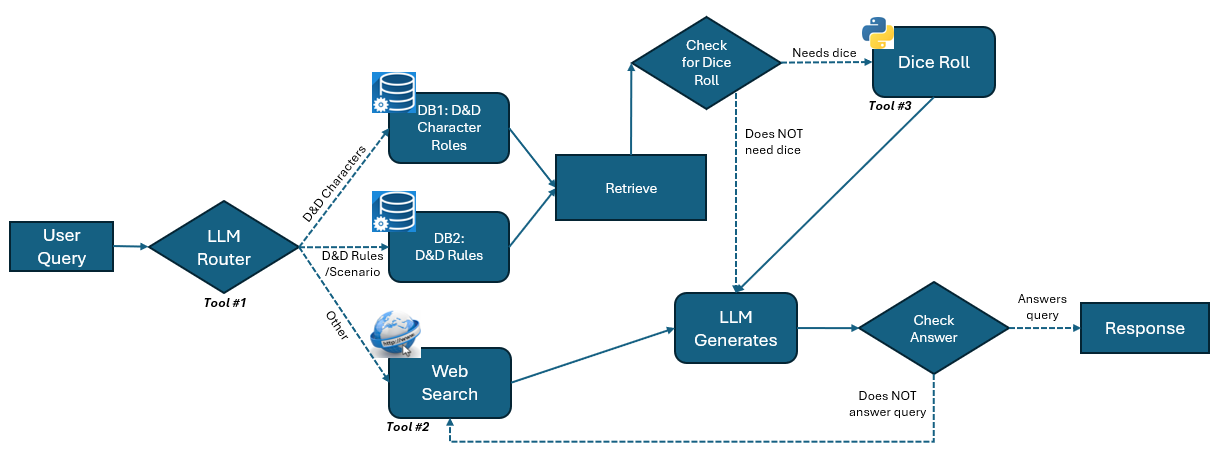

### HW3 Grading Rubric

| Criterion                  | Points |
|----------------------------|--------|
| Functioning RAG agentic workflow | 40 |
| Verified use of each DB (10 pts each) | 10 |
| Verified use of Websearch tool | 10 |
| Verified use of Dice tool | 10 |
| Matching Logic diagram | 10 |
| Conceptual questions (not included in notebook) | 20 |
| **Total Points** | **100**|

*Notes:*
 * *Functioning workflow is defined as the workflow accepts a prompt and successfully terminates, providing a response (regardless of its accuracy).*
 * *Tool use verified through logging and state tracking.*


**Bonus**: If the tool accepts and successfully terminates with a response, all 40 points will be awarded, regardless of the accuracy of the provided response. Bonus points will be awarded for the number of accurate responses provided using the following scale:
  * 4 accurate responses = 4 bonus points
  * 5 accurate responses = 6 bonus points
  * 6 accurate responses = 8 bonus points
  * 7+ accurate responses = 10 bonus points

## -------- CODE SECTION --------

In [ ]:
# Ensure I'm using the hw3 virtual environment, not the llms_for_oa one with the same name
import sys
sys.executable

'/home/jack/oa4910/Homework/Homework_3/.venv/bin/python'

### Setup

In [2]:
# - Run `uv sync` to get added packages
!uv sync

Resolved 300 packages in 13ms
Audited 289 packages in 15ms


In [3]:
# Standard library
import json
import logging
import operator
import os
import sys
from pathlib import Path
from pprint import pprint
from types import SimpleNamespace
from typing import Annotated, List, Literal
from tqdm import tqdm
import random

# Third party
import requests
from IPython.display import Image, display
from typing_extensions import NotRequired, TypedDict

# Pydantic
from pydantic import BaseModel, Field

# OpenAI
from openai import OpenAI

# LangChain Core
from langchain_core.documents import Document
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnableLambda, RunnablePassthrough
from langchain_core.tools import tool
from langchain_core.messages import ToolMessage

# LangChain potpurri
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEndpointEmbeddings, HuggingFaceEmbeddings
from langchain_chroma import Chroma
from chromadb.utils.embedding_functions import HuggingFaceEmbeddingServer

# LangChain OpenAI
from langchain_openai import ChatOpenAI

# LangChain Community
from langchain_community.tools import DuckDuckGoSearchResults
from langchain_community.document_loaders import PyMuPDFLoader

# LangGraph
from langgraph.graph import StateGraph, END

# Add the PARENT directory (oa4910) to sys.path and load helper functions
sys.path.append(str(Path.cwd().parent))
from helper_code.rag.load_dataset import setup_embedding_function, load_db_from_dir, load_vectorstore

### Intialize LLMs

In [4]:
## GREEN ##
# No change from Lsn8 ipynb
API_KEY = "sk-UtrV9i5fFenmG6hvMss71A"
BASE_URL = "http://trac-malenia.ern.nps.edu:8080/inference/v1"

# Check the models available
model_ids = []

try:
    response = requests.get(
        f"{BASE_URL}/models",
        headers={"Authorization": f"Bearer {API_KEY}"}
    )
    response.raise_for_status()  
    info = response.json()
    
    for model in info['data']:
        model_ids.append(model['id'])
    model_id = info['data'][0]['id']
    print(f"Available Models: {model_ids}")
    print(f"\nDefault Selected Model Id: {model_id}")
except Exception as e:
    print(f"Error accessing model endpoint: {e}")

Available Models: ['TRAC-MTRY/traclm-v4-7b-instruct', 'google/gemma-3-27b-it', 'casperhansen/llama-3.3-70b-instruct-awq', 'allenai/Olmo-3-7B-Instruct', 'Qwen/Qwen3-30B-A3B-Thinking-2507-FP8', 'Voxtral-Mini-3B-2507', 'Qwen/Qwen3-30B-A3B-Instruct-2507-FP8']

Default Selected Model Id: TRAC-MTRY/traclm-v4-7b-instruct


In [8]:
## YELLOW ##
# choose your desired model by updating model_id -- see the returned Available Models above and index based off that list
model_id = model_ids[0]
print(model_id)

# Create a model instance to use as your router -- HINT: which of the available models supports tool calling?
llm_md_tools = ChatOpenAI(
    base_url=BASE_URL,
    model=model_id,
    api_key=API_KEY,
    temperature=0,  
    name= "TRACLM-instruct" # Name the LLM for langchain
)

# test the model's responsiveness
prompt = "Briefly explain the concept of Dungeons and Dragons (D&D)?"

for chunk in llm_md_tools.stream(prompt):
    print(chunk.content, end='')

TRAC-MTRY/traclm-v4-7b-instruct
Dungeons and Dragons (D&D) is a tabletop role-playing game where players create characters and embark on adventures in a fantasy world. The game is guided by a Dungeon Master (DM), who acts as the game's storyteller and referee. Players use dice to determine the outcome of their actions and decisions, and the DM uses these rolls to create challenges and obstacles for the players to overcome. The game encourages creativity, problem-solving, and social interaction among players.

In [7]:
## YELLOW ## 
# Create a model instance to generate your responses, if you want to use a different one than above
# You can choose whichever model you'd like, but not all are likely to perform well for the given eval prompts
llm_gen_tools = ChatOpenAI(
    base_url=BASE_URL,
    model= model_ids[2],
    api_key=API_KEY,
    temperature=0.3,
    name="llama3-instruct"
)

# test the model's responsiveness
prompt = "Where was Donald Trump born?"
result_gen = llm_gen_tools.invoke(prompt)

print(f"General- {result_gen.content[:165]}")

General- Donald Trump, the 45th President of the United States, was born on June 14, 1946, in Queens, New York City, New York. Specifically, he was born at Jamaica Hospital M


### Setup logging

In [9]:
## GREEN ##
# Setup logging for tool creation and testing
logger = logging.getLogger("agentic_workflow")
logger.setLevel(logging.DEBUG)

# Add console handler if not already present
if not logger.handlers:
    console_handler = logging.StreamHandler()
    console_handler.setLevel(logging.DEBUG)
    formatter = logging.Formatter('%(levelname)s - %(message)s')
    console_handler.setFormatter(formatter)
    logger.addHandler(console_handler)

logger.info("Logger configured for tool creation and testing")

INFO - Logger configured for tool creation and testing


In [10]:
## GREEN ##
# create logging runnable to track router chain execution
def logging_helper(state: dict) -> dict:
    """Log internal chain steps"""
    logger.debug(f"Intermediary State: '{state}'")
    return state

r_logger = RunnableLambda( logging_helper, name= "log chain state")

### Build the vectorestores

In [11]:
## GREEN ##
# Build database of character descriptions
server_url = "http://trac-malenia.ern.nps.edu:8080/gpu5/embed"
setup_embedding_function(server_url)

chars_directory = "./docs/characters"
chars_chromadb_path = "./databases/characters"
characters_db = load_db_from_dir(chars_directory, chars_chromadb_path)

chars_vectorstore_path: str = "./databases/characters"
chars_vectorstore = load_vectorstore(chars_vectorstore_path)

Embedding function set from server
Total Pages: 4
Total Chunks: 16
Added IDs to 16 chunks
Embedding function set from server
Adding documents to vectorstore...


100%|██████████| 1/1 [00:00<00:00,  3.11it/s]


Total documents processed: 16
Documents in vectorstore: 16
Embedding function set from server
Loaded vectorstore with 16 documents


In [13]:
## RED ##
# Build database of rules, scenario, and campaign documents
server_url = "http://trac-malenia.ern.nps.edu:8080/gpu5/embed"
setup_embedding_function(server_url)

scen_directory = "./docs/rules_scenarios"
scen_chromadb_path = "./databases/rules_scenarios"
scen_db = load_db_from_dir(scen_directory, scen_chromadb_path)

scen_vectorstore_path: str = "./databases/rules_scenarios"
scen_vectorstore = load_vectorstore(scen_vectorstore_path)

# mimic the cell above swapping out 'chars' prefix for 'scen' and updating the paths


Embedding function set from server
Total Pages: 580
Total Chunks: 3885
Added IDs to 3885 chunks
Embedding function set from server
Adding documents to vectorstore...


100%|██████████| 122/122 [00:29<00:00,  4.09it/s]



Total documents processed: 3885
Documents in vectorstore: 3885
Embedding function set from server
Loaded vectorstore with 3885 documents


### Build the router

In [21]:
## YELLOW ##
# Provide instructions for the routing tool, and the available routes. See Lsn8 for example.
# Instructions should be something like use this vectorstore for this, use that one for that, otherwise use...
class RouteSelection(BaseModel):
    """Route selection for query processing.

    The character vectorstore contains documents related to the creation of characters in the game "Dungeons and Dragons". The rules scenarios 
    vectorstore contains documents related to the rules of the game "Dungeons and Dragons".
    Use 'chars_vectorstore' for questions about Dungeons and Dragons characters.
    Use 'scen_vectorstore' for questions about the rules of the game Dungeons and Dragons.
    Use 'websearch' for everything else.
    """
    route: Literal["chars_vectorstore", "scen_vectorstore", "websearch"] = Field(
        description="Selected route based on query type."
    )

@tool(args_schema=RouteSelection)
def select_route(route: str) -> str:
    """Route user queries to the appropriate source.
    The character vectorstore contains documents related to the creation of characters in the game "Dungeons and Dragons". The rules scenarios 
    vectorstore contains documents related to the rules of the game "Dungeons and Dragons".

    Use 'chars_vectorstore' for questions about Dungeons and Dragons characters.
    Use 'scen_vectorstore' for questions about the rules of the game Dungeons and Dragons.
    Use 'websearch' for everything else.
    """
    return route

llm_router = llm_md_tools.bind_tools([select_route], tool_choice='select_route')

# Router instructions
router_prompt = ChatPromptTemplate.from_messages([
    ("system", """You are a query routing assistant. Your job is to analyze user queries and route them to the appropriate source. 

The character vectorstore contains documents related to the creation of characters in the game "Dungeons and Dragons". The rules scenarios 
vectorstore contains documents related to the rules of the game "Dungeons and Dragons".

ROUTING RULES:
Route to 'chars_vectorstore' for questions about Dungeons and Dragons characters. If the query contains proper names, unusual names, fantasy-style
names, abilities, languages, backgrounds, races, classes, or personal details, it is a character question.
     
Route to 'scen_vectorstore' for questions about the rules of the game Dungeons and Dragons. If the query asks about gameplay, rules, adjudication,
dice rolls, the Dungeon Master, combat, spells or how to perform certain actions, it is a rules question.
     
Route to 'websearch' for topics outside of Dungeons and Dragons characters and rules.


"""),
    ("human", "{query}")
])

# Create the router chain
router_chain = router_prompt | r_logger | llm_router

# Test -- route should = chars_vectorstore
result = router_chain.invoke("Who is Edrin Mossfield?") # chars_vectorstore
#result = router_chain.invoke("How do players determine if a move is legal in Dungeons and Dragons?") # scen_vectorstore
#result = router_chain.invoke("Where can I buy the materials needed to play Dungeons and Dragons?") # websearch
print(result)
print(result.tool_calls[0]["args"])

content='' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 11, 'prompt_tokens': 472, 'total_tokens': 483, 'completion_tokens_details': None, 'prompt_tokens_details': None}, 'model_provider': 'openai', 'model_name': 'nvidia_nim/TRAC-MTRY/traclm-v4-7b-instruct', 'system_fingerprint': None, 'id': 'chatcmpl-c1fd285582fc49c885012790cf3abfb0', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_run--019c676a-fffa-7fe3-83e8-5c0b7ffe01df-0' tool_calls=[{'name': 'select_route', 'args': {'route': 'chars_vectorstore'}, 'id': 'chatcmpl-tool-a803006e231141e4a8594d8304de29af', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 472, 'output_tokens': 11, 'total_tokens': 483, 'input_token_details': {}, 'output_token_details': {}}
{'route': 'chars_vectorstore'}


In [22]:
## GREEN ##
# OPTIONAL
# Check functionality of the router - first two questions should route to chars_vectorstore, next three to scen_vectorstore, and last two to websearch
test_questions = [
    "Who is Edrin Mossfield?",
    "How many languages does Seris Larkspur speak?",
    "Who participated in the campaign in Kestrelford?",
    "What is the role of the Dungeon Master?",
    "I want to attack another D&D player. Roll the dice for me and adjudicate the move.",
    "Who is the president?",
    "Who is Bill Belichick?",
]

logger.setLevel(logging.INFO)
results = router_chain.batch(test_questions)
for question, result in zip(test_questions, results):
    print(question, result.tool_calls[0]["args"])

Who is Edrin Mossfield? {'route': 'chars_vectorstore'}
How many languages does Seris Larkspur speak? {'route': 'chars_vectorstore'}
Who participated in the campaign in Kestrelford? {'route': 'scen_vectorstore'}
What is the role of the Dungeon Master? {'route': 'scen_vectorstore'}
I want to attack another D&D player. Roll the dice for me and adjudicate the move. {'route': 'scen_vectorstore'}
Who is the president? {'route': 'websearch'}
Who is Bill Belichick? {'route': 'websearch'}


### Build websearch tool

In [23]:
## GREEN ##
# create websearch object
websearch = DuckDuckGoSearchResults(output_format="json",
                                    num_results=3,
                                    )

# verify websearch responsiveness
json.loads(websearch.invoke("Where is the US President from?"))

Impersonate 'chrome_114' does not exist, using 'random'


[{'snippet': 'Since the ratification of the Twenty-second Amendment to the United States Constitution in 1951, no person may be elected president more than twice, and no one who has served more than two years of a term to which someone else was elected may be elected more than once. See full list on en.wikipedia.org Since the Twenty-second Amendment was adopted in 1951, the American presidency has been limited to a maximum of two terms. Click on a president below to learn more about each presidency through an interactive timeline. See full list on britannica.com View all 21 of the 50 states have been the birthplace of a president . Number of Presidents of the United States born by state. Trump is President of the United States and is a Republican. He has served since Jan. 20, 2025. Trump’s current term ends on Jan. 20, 2029. He is 79 years old. He was previously President of the United States as a Republican from 2017 to Jan. 20, 2021. Learn more about the Presidents of the United Stat

### Build dice roll tool

In [25]:
## RED ##
# build a function to simulate rolling a twenty-sided die
# function must be named roll_dice and return result

@tool
def roll_dice() -> int:
    '''Return the outcome of one roll of a 20-sided die.'''
    return random.randint(1,20)

# Test (optional)
roll = roll_dice.invoke({"query": "I am rolling for an attack roll"})
print(f"You rolled a {roll}")

You rolled a 3


### Link tools together with LangGraph

In [26]:
## GREEN ##
class GraphState(TypedDict):
    """State for the agentic RAG workflow.

    Only 'question' is required. All other fields have defaults via init_graph_state().
    """
    question: str
    route: str | None
    generation: NotRequired[str]
    do_websearch: NotRequired[str]
    max_retries: NotRequired[int]
    gen_attempts: NotRequired[Annotated[int, operator.add]]
    documents: NotRequired[list[tuple[Document, int]]]
    k: NotRequired[int]
    dice_roll: NotRequired[int | None]
    websearch_retries: NotRequired[Annotated[int, operator.add]]  # ← ADD THIS
    max_websearch_retries: NotRequired[int]
    route_after_check: NotRequired[str]

### Make graph nodes

In [27]:
## GREEN ##
def init_graph_state(state: dict) -> GraphState:
    """Initialize GraphState with defaults from partial input.
    
    Takes a dict with at minimum 'question' key and fills in defaults for other fields.
    """
    logger.info("NODE: Initialize State")
    logger.debug(f"  Input state: {state}")
    
    # Fill in defaults for any missing keys
    initialized: GraphState = {
        "question": state["question"],
        "route": state.get("route", None),
        "generation": state.get("generation", ""),
        "do_websearch": state.get("do_websearch", "no"),
        "max_retries": state.get("max_retries", 3),
        "gen_attempts": state.get("gen_attempts", 0),
        "documents": state.get("documents", []),
        "k": state.get("k", 3),
        "websearch_retries": state.get("websearch_retries", 0),
        "max_websearch_retries": state.get("max_websearch_retries", 1),
        "dice_roll": state.get("roll_dice"),
    }
    
    logger.debug(f"  Initialized state keys: {list(initialized.keys())}")
    return initialized

# Test (optional)
initialized_state = init_graph_state({"question": "Who is the US President?"})
print(f"\nInitialized state: {initialized_state}")

INFO - NODE: Initialize State



Initialized state: {'question': 'Who is the US President?', 'route': None, 'generation': '', 'do_websearch': 'no', 'max_retries': 3, 'gen_attempts': 0, 'documents': [], 'k': 3, 'websearch_retries': 0, 'max_websearch_retries': 1, 'dice_roll': None}


In [28]:
## GREEN ##
# build route question node
def route_question_node(state: dict) -> dict:
    """Determine routing decision and persist it in state"""
    logger.info("NODE: Route Question - Determining data source")

    question = state["question"]
    logger.debug(f"  Question to route: {question}")

    result = router_chain.invoke({"query": question})
    route = result.tool_calls[0]["args"]["route"]

    logger.info(f"  Routing decision: {route}")
    return {"route": route}


In [31]:
## YELLOW ##
# retrieve from vectorstore node
def semantic_retrieve_w_scores(state: dict) -> dict:
    """Retrieve documents and add them to the running state."""
    
    logger.info("NODE: Semantic Retriever")
    logger.info(f"  Retriever sees route={state.get('route')!r} key={list(state.keys())}")
    query = state["question"]
    k = state.get("k", 3)

    route = state.get("route")

    # insert if/else statement here assigning which vectorstore to use
    # HINT: if route = characters, vectorstore = characters else vectorstore = scenarios
    if route == "chars_vectorstore":
        vectorstore = chars_vectorstore

    elif route == "scen_vectorstore":
        vectorstore = scen_vectorstore

    else:
        return {"documents": []} # Don't attempt to retrieve docs or score them if we are doing a web search
    
    logger.debug(f"  Query: '{query}'")
    logger.debug(f"  Retrieving top {k} documents")
    
    docs_with_scores = vectorstore.similarity_search_with_relevance_scores(query, k=k)
    
    logger.info(f"  Retrieved {len(docs_with_scores)} documents")
    for i, (doc, score) in enumerate(docs_with_scores):
        logger.debug(f"  Doc {i}: score={score:.3f}, source={doc.metadata.get('source', 'unknown')}, content= {doc.page_content[:50].strip()}")
    
    # Return updated state with documents added
    return {"documents": docs_with_scores}

semantic_retriever = RunnableLambda(
    semantic_retrieve_w_scores,
    name="semantic_retriever"
)

# test (optional)
results = semantic_retriever.invoke({"question": "Edrin Mossfield", "k": 3, "route": "chars_vectorstore"})

INFO - NODE: Semantic Retriever
INFO -   Retriever sees route='chars_vectorstore' key=['question', 'k', 'route']
INFO -   Retrieved 3 documents


In [42]:
## YELLOW ##
# dice check and roll node
def check_and_roll_dice(state: dict) -> dict:
    """Check if the question requires a dice roll and perform it if needed."""
    logger.info("NODE: Check and Roll Dice")
    
    question = state['question'].lower()
    
    # Provide a list of keywords that indicate dice rolling is needed
    dice_keywords = ["roll", "dice", "die", "20", "twenty", "sided", "sides", "rolling", "toss", "tossing", "throw", "throwing"]
    
    needs_dice = any(keyword in question for keyword in dice_keywords)
    
    if needs_dice:
        logger.info("  Dice roll detected in question")
        roll_result = roll_dice.invoke({})
        logger.info(f"  Rolled d20: {roll_result}")
        
        # Add dice roll info to state
        return {
            "dice_roll": roll_result,
        }
    else:
        logger.info("  No dice roll needed")
        return {"dice_roll": None}

In [33]:
## GREEN ##
# Websearch Node
def websearch_node(state):
    """Perform web search and format results as documents"""
    logger.info("NODE: Websearch - Performing web search")
    question = state['question']
    logger.debug(f"  Search query: {question}")

    # Perform websearch
    search_results = websearch.invoke(question)
    logger.debug(f"  Raw websearch response: {search_results[:200]}...")

    # Convert search results to document format
    import json
    results_list = json.loads(search_results)

    web_documents = []
    for result in results_list:
        doc_content = f"Title: {result['title']}\nSnippet: {result['snippet']}\nLink: {result['link']}"
        # Create a simple namespace object to mimic Document structure
        from types import SimpleNamespace
        doc = SimpleNamespace(
            page_content=doc_content,
            metadata={'source': result['link'], 'title': result['title']}
        )
        web_documents.append((doc, 1.0))  # Add dummy score to mirror 

    logger.info(f"  Websearch returned {len(web_documents)} results")
    logger.debug(f"  Result titles: {[r['title'] for r in results_list]}")
    return {"documents": web_documents}

# Test (optional)
test_state = {
    "question": "Where is the President from?"
}
result = websearch_node(test_state)

INFO - NODE: Websearch - Performing web search
INFO -   Websearch returned 3 results


In [49]:
## YELLOW ##
# Provide prompt template -- should provide some instructions for the model. Be sure to cover when to say "I don't know" and how to handle dice rolls
rag_template = (
    ChatPromptTemplate.from_messages([
        ("system", """You are a helpful assistant that answers questions based on the provided documents and any additional context passed into the prompt. \
         
         GENERAL RULES:
         1) Use the provided documents as the source of truth concerning the game Dungeons & Dragons.
         2) If the documents do not contain the information necessary to answer the question, respond with "I don't know".
         3) Do not generate any novel information not supported by documet content or tool outputs.
         
         DICE ROLL RULES:
         1) If a dice roll result is provided, use it as context to guide your response.
         2) Do not fabricate dice rolls. Only use ones explicitly provided as tool outputs or as user prompt data.

         RULES FOR WHEN NO DOCUMENTS ARE RETRIEVED:
         1) If no documents are provided and no tool results are relevant, answer using general knowledge ONLY if the question does not have to do with Dungeons & Dragons.
         2) If no documents are provided, no tool results are relevant, and the question IS about Dungeons & Dragons, respond with "I don't know".

         TOOL-AWARE BEHAVIOR RULES:
         1) You will sometimes receive tool results (either dice rolls or websearch results). If these are provided, use them in generating your response.
         2) Do NOT call tools from this prompt. Tool calls are to take place at an earlier stage of the workflow.

         """),
        ("human", """Documents:
{context}
{dice_info}

Question: {query}

Answer based on the documents above:""")
    ])
    .with_config(run_name="RAG_Prompt_Template")
)

def generate_response(state: dict) -> dict:
    """Generate LLM response and add it to the running state."""
    logger.info("NODE: Generate Response")
    question = state['question']
    documents = state['documents']
    dice_roll = state.get('dice_roll')
    
    logger.debug(f"  Question: {question}")
    logger.debug(f"  Using {len(documents)} documents for context")
    logger.debug(f"  Dice roll: {dice_roll}")

    context = "\n\n---\n\n".join([doc.page_content for doc, _ in documents])
    
    # Add dice roll information if present
    dice_info = ""
    if dice_roll is not None:
        dice_info = f"Dice Roll Result: You rolled a d20 and got {dice_roll}."

    logger.debug(f"  Context preview: {context[:100]}...")
    logger.debug(f"  Context length: {len(context)} chars")
    
    # Create the prompt from state
    prompt = rag_template.invoke({"query": question, "context": context, "dice_info": dice_info})
    logger.info(f"  Prompt created with {len(prompt.messages)} messages")
    logger.debug(f"  Formatted prompt messages: {[m.type for m in prompt.messages]}")
    
    # Invoke LLM and generate
    logger.info("  Invoking LLM...")
    msg = llm_gen_tools.invoke(prompt.messages)

    # Parse to string
    generation_text = getattr(msg, "content", "") or ""
    logger.info(f"  Generated response ({len(generation_text)} chars)")
    logger.debug(f"  Response preview: {generation_text[:200]}...")
    
    return {"generation": generation_text, "gen_attempts": 1}

generate_response_runnable = RunnableLambda(generate_response, name="generate_response")

# Test (optional)
test_dict= {
    "question": "test question",
    "documents": [
        [SimpleNamespace(page_content="chunk1 ..."), .5],
        [SimpleNamespace(page_content="chunk2 ..."), .5],
        [SimpleNamespace(page_content="chunk3 ..."), .5]
    ]
}

updated_state = generate_response_runnable.invoke(test_dict)

INFO - NODE: Generate Response
INFO -   Prompt created with 2 messages
INFO -   Invoking LLM...
INFO -   Generated response (12 chars)


### Make graph edges

In [50]:
## GREEN ##
# Route Question Edge
def route_question_edge(state: dict) -> str:
    """Choose graph edge based on persisted route"""
    route = state.get("route")

    logger.info(f"EDGE: route_question_edge sees route={route!r}") #keys={list(state.keys())}")
    
    if route == "websearch":
        return "websearch"
    return "retrieve"

idk_phrases = [
    "I don't know",
    "I do not know",
]

# check if generation based on retrieval contains idk
def needs_websearch_from_generation(text: str) -> bool:
    """
    Return True if generation contains any IDK phrase (substring match).
    """
    if not text:
        return True

    text_lc = text.lower()
    return any(phrase.lower() in text_lc for phrase in idk_phrases)

# check if generation based on retrieval contains idk
def check_answer_node(state: dict) -> dict:
    """
    Post-generate checker.
    Sets state['route_after_check'] to 'websearch' or 'final'
    and increments state['websearch_retries'] when routing to websearch.
    """
    
    logger.info("NODE: Checking if retrieved answer contains IDK")

    generation = state.get("generation", "")
    documents = state.get("documents", []) 

    # Use this entire commented section if you want to preview the retrieved context as part of your output
    # ---- Build context preview ----
    context_preview_parts = []
    for i, (doc, score) in enumerate(documents[:2]):  # limit to first 2 docs
        snippet = (
            doc.page_content
            .replace("\n", " ")
            .strip()[:350]
        )
        context_preview_parts.append(
            f"[doc{i} score={score:.2f}] {snippet}"
        )

    context_preview = " | ".join(context_preview_parts) or "<no documents>"

    # # ---- Generation preview ----
    gen_preview = generation.replace("\n", " ")[:120] if generation else "<empty>"

    # # ---- Side-by-side log ----
    logger.info(
        "\n"
        "  ===== RAG CHECK =====\n"
        f"  Docs count : {len(documents)}\n"
        f"  Context    : {context_preview}\n"
        f"  Generation : {gen_preview}\n"
        "  ====================="
    )
    # end of commented section for previewing retrieved context
    
    #logger.info()

    # Get current retry count (default to 0 if not set)
    retries = int(state.get("websearch_retries", 0))
    max_retries = int(state.get("max_websearch_retries", 1))

    #logger.info(f" retries={retries}, max_retries={max_retries}")
    logger.info(f"  Current retries={retries}, max_retries={max_retries}")
    #logger.debug(f" Generation preview: {generation[:100]}")

    if needs_websearch_from_generation(generation):
        
        if retries >= max_retries:
            logger.info("  IDK detected but max retries reached -> final")
            return {
                "route_after_check": "final",
            }

        logger.info(f"  IDK detected -> websearch (attempt {retries + 1}/{max_retries})")
        # Increment retry counter when routing to websearch
        return {
            "route_after_check": "websearch",
            "websearch_retries": 1,  
        }

    logger.info("  Generation is acceptable -> final")
    return {
        "route_after_check": "final",
    }

def decide_after_check(state: dict) -> str:
    return state.get("route_after_check", "final")

In [51]:
## GREEN ##
# dice edge function
def decide_dice_or_generate(state: dict) -> str:
    """Decide whether to check for dice rolling or go straight to generation."""
    question = state['question'].lower()
    dice_keywords = ["roll", "dice", "die", "20", "twenty", "sided", "sides", "rolling", "toss", "tossing", "throw", "throwing"]
    needs_dice = any(keyword in question for keyword in dice_keywords)
    
    if needs_dice:
        logger.info("EDGE: Question needs dice roll -> check_dice")
        return "check_dice"
    else:
        logger.info("EDGE: No dice needed -> generate")
        return "generate"

### Build and compile the graph

In [52]:
## YELLOW ##
# Create the graph
workflow = StateGraph(GraphState)

# Add the appropriate nodes
workflow.add_node("init_state", init_graph_state)
workflow.add_node("route_question", route_question_node)
workflow.add_node("semantic_retriever_and_grader", semantic_retrieve_w_scores)
workflow.add_node("check_and_roll_dice", check_and_roll_dice)
workflow.add_node("websearch", websearch_node)
workflow.add_node("generate_response", generate_response)
workflow.add_node("check_answer", check_answer_node)

# Start -> init_state
workflow.set_entry_point("init_state")

# Add edges
# init_state -> route question
workflow.add_edge("init_state", "route_question")

# route_question -> websearch or retrieve (conditional)
# (if prompt is D&D related -> retrieve else websearch)
workflow.add_conditional_edges("route_question", 
                  route_question_edge,
                  {
                    "websearch":"websearch", 
                    "retrieve": "semantic_retriever_and_grader" 
                  }
                  )

# retrieve -> check_dice OR generate (conditional)
# (if dice related then roll dice and add to context else generate)
workflow.add_conditional_edges("semantic_retriever_and_grader",
                               decide_dice_or_generate,
                               {
                                   "check_dice": "check_and_roll_dice",
                                   "generate": "generate_response"
                               })

# check_dice -> generate
workflow.add_edge("check_and_roll_dice", "generate_response")

# websearch -> generate
workflow.add_edge("websearch", "generate_response")

# generate -> check answer (to see if answer is contained in vectorstore)
workflow.add_edge("generate_response", "check_answer" )

# check_answer -> websearch or END (conditional)
# (if retrieval doesn't contain answer conduct websearch else END)
workflow.add_conditional_edges("check_answer",
                               decide_after_check,
                               {
                                   "websearch":"websearch",
                                   "final": END
                               }
                               )

# Compile the graph
app = workflow.compile()

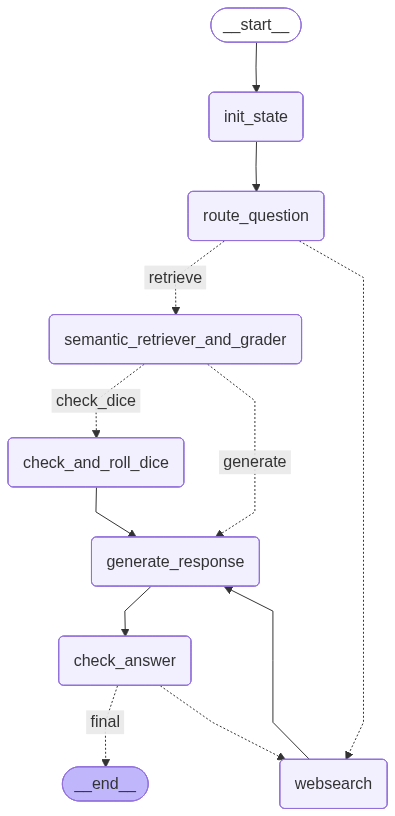

In [40]:
## GREEN ##
# visualize the graph structure
# HINT: this should match the provided logic diagram
display(Image(app.get_graph().draw_mermaid_png()))

### Test your agentic workflow with these examples -- this section is not graded. However, it is recommended you create a few extra examples to confirm that all routing options are successful.

In [53]:
question = "Who is Edrin Mossfield?"
logger.setLevel(logging.INFO)
result = app.invoke({"question": question})

print()
print(f"=====================")
print(f"Question: {question}")
print(f"\nAnswer: {result['generation']}")
print(f"\nNumber of documents retrieved: {len(result['documents'])}")
print(f"\nGeneration attempts: {result['gen_attempts']}")

INFO - NODE: Initialize State
INFO - NODE: Route Question - Determining data source
INFO -   Routing decision: chars_vectorstore
INFO - EDGE: route_question_edge sees route='chars_vectorstore'
INFO - NODE: Semantic Retriever
INFO -   Retriever sees route='chars_vectorstore' key=['question', 'route', 'generation', 'do_websearch', 'max_retries', 'gen_attempts', 'documents', 'k', 'dice_roll', 'websearch_retries', 'max_websearch_retries']
INFO -   Retrieved 3 documents
INFO - EDGE: No dice needed -> generate
INFO - NODE: Generate Response
INFO -   Prompt created with 2 messages
INFO -   Invoking LLM...
INFO -   Generated response (403 chars)
INFO - NODE: Checking if retrieved answer contains IDK
INFO - 
  ===== RAG CHECK =====
  Docs count : 3
  Context    : [doc0 score=0.52] Edrin Mossﬁeld Backstory  For as long as anyone in the hamlet of Brindlewick could remember, Edrin Mossﬁeld had worked  the same stretch of land. The ﬁelds changed with the seasons, neighbors came and went, and the  o


Question: Who is Edrin Mossfield?

Answer: Edrin Mossfield is a farmer from the hamlet of Brindlewick who has been working the same stretch of land for decades, yet appears to have not aged normally. Edrin has recently discovered that they possess magical abilities, which they had been trying to keep hidden, but eventually decided to leave their home to join a group called the Data-Driven Delvers (D3) in search of answers and a new beginning.

Number of documents retrieved: 3

Generation attempts: 1


In [54]:
question = "Who is Bill Belichick?"
logger.setLevel(logging.INFO)
result = app.invoke({"question": question})

print()
print(f"=====================")
print(f"Question: {question}")
print(f"\nAnswer: {result['generation']}")
print(f"\nNumber of documents retrieved: {len(result['documents'])}")
print(f"\nGeneration attempts: {result['gen_attempts']}")

INFO - NODE: Initialize State
INFO - NODE: Route Question - Determining data source
INFO -   Routing decision: websearch
INFO - EDGE: route_question_edge sees route='websearch'
INFO - NODE: Websearch - Performing web search
INFO -   Websearch returned 3 results
INFO - NODE: Generate Response
INFO -   Prompt created with 2 messages
INFO -   Invoking LLM...
INFO -   Generated response (599 chars)
INFO - NODE: Checking if retrieved answer contains IDK
INFO - 
  ===== RAG CHECK =====
  Docs count : 3
  Context    : [doc0 score=1.00] Title: Bill Belichick - Wikipedia Snippet: William Stephen Belichick (/ ˈbɛlɪtʃɪk, - tʃɛk / ⓘ BEL-itch-ik, -ek; born April 16, 1952) is an American football coach who is the head coach of the University of North Carolina Tar Heels. Link: https://en.wikipedia.org/wiki/Bill_Belichick | [doc1 score=1.00] Title: Bill Belichick Age, Height, Girlfriend, Net Worth And More Bill Belichick | Record, Hall of Fame, New England Patriots ... Bill Belichick Age, Height, Girl


Question: Who is Bill Belichick?

Answer: Bill Belichick is an American football coach who is widely regarded as the greatest professional gridiron football coach in history. He was born on April 16, 1952, in Nashville, Tennessee, and is the son of Jeannette and Steve Belichick, with Steve being an assistant collegiate football coach. Bill Belichick is best known for his successful tenure with the New England Patriots, where he led the team to six Super Bowl titles (2002, 2004, 2005, 2015, 2017, and 2019) during his 24 seasons as the team's head coach. He is currently the head coach at the University of North Carolina at Chapel Hill.

Number of documents retrieved: 3

Generation attempts: 1


In [ ]:
# Question that purports to be D&D-related but is about something fake. What will the llm do?
question = "What are the official D&D rules for the ritual of the sapphire veil?"
logger.setLevel(logging.INFO)
result = app.invoke({"question": question})

print()
print(f"=====================")
print(f"Question: {question}")
print(f"\nAnswer: {result['generation']}")
print(f"\nNumber of documents retrieved: {len(result['documents'])}")
print(f"\nGeneration attempts: {result['gen_attempts']}") # Good, it tells us it doesn't know

INFO - NODE: Initialize State
INFO - NODE: Route Question - Determining data source
INFO -   Routing decision: scen_vectorstore
INFO - EDGE: route_question_edge sees route='scen_vectorstore'
INFO - NODE: Semantic Retriever
INFO -   Retriever sees route='scen_vectorstore' key=['question', 'route', 'generation', 'do_websearch', 'max_retries', 'gen_attempts', 'documents', 'k', 'dice_roll', 'websearch_retries', 'max_websearch_retries']
INFO -   Retrieved 3 documents
INFO - EDGE: No dice needed -> generate
INFO - NODE: Generate Response
INFO -   Prompt created with 2 messages
INFO -   Invoking LLM...
INFO -   Generated response (199 chars)
INFO - NODE: Checking if retrieved answer contains IDK
INFO - 
  ===== RAG CHECK =====
  Docs count : 3
  | [doc1 score=0.56] D&D Basic Rules (Version 1.0). Not for resale. Permission granted to print and photocopy this document for personal use only. 81 Part 3  The Rules of Magic RICHARD WHITTERS
  Generation : I don't know. The documents provided do not


Question: What are the official D&D rules for the ritual of the sapphire veil?

Answer: I don't know. The documents provided do not contain information about the "ritual of the sapphire veil". They discuss general rules for spellcasting and rituals in Dungeons & Dragons, but do not mention this specific ritual.

Number of documents retrieved: 3

Generation attempts: 2


In [ ]:
# Another Question about something fake:
question = "What does the dungeon master's guide say about the trial of the ninefold path?"
logger.setLevel(logging.INFO)
result = app.invoke({"question": question})

print()
print(f"=====================")
print(f"Question: {question}")
print(f"\nAnswer: {result['generation']}")
print(f"\nNumber of documents retrieved: {len(result['documents'])}")
print(f"\nGeneration attempts: {result['gen_attempts']}") # Good, it again tells us it doesn't know

INFO - NODE: Initialize State
INFO - NODE: Route Question - Determining data source
INFO -   Routing decision: scen_vectorstore
INFO - EDGE: route_question_edge sees route='scen_vectorstore'
INFO - NODE: Semantic Retriever
INFO -   Retriever sees route='scen_vectorstore' key=['question', 'route', 'generation', 'do_websearch', 'max_retries', 'gen_attempts', 'documents', 'k', 'dice_roll', 'websearch_retries', 'max_websearch_retries']
INFO -   Retrieved 3 documents
INFO - EDGE: No dice needed -> generate
INFO - NODE: Generate Response
INFO -   Prompt created with 2 messages
INFO -   Invoking LLM...
INFO -   Generated response (85 chars)
INFO - NODE: Checking if retrieved answer contains IDK
INFO - 
  ===== RAG CHECK =====
  Docs count : 3
  Context    : [doc0 score=0.58] Part 4 is especially for the Dungeon Master. It contains  instructions for how to challenge the player characters  with adversaries that are a good test of their abilities,  plus dozens of ready-to-use monster description


Question: What does the dungeon master's guide say about the trial of the ninefold path?

Answer: I don't know. 

The provided documents do not mention the "dungeon master's guide" or the "trial of the ninefold path". They discuss the "Rite of the Nine" event in Destiny 2 and the "Trial of One" in Deepwoken, but do not provide information about the specific topic you asked about.

Number of documents retrieved: 3

Generation attempts: 2


### Evaluation -- The following prompts will be used to evaluate your tool and award bonus points for accuracy.

In [58]:
question = "Ronan Hale is a character in Dungeons and Dragons. Where is he from?"
logger.setLevel(logging.INFO)
result = app.invoke({"question": question})

print()
print(f"=====================")
print(f"Question: {question}")
print(f"\nAnswer: {result['generation']}")
print(f"\nNumber of documents retrieved: {len(result['documents'])}")
print(f"\nGeneration attempts: {result['gen_attempts']}")

INFO - NODE: Initialize State
INFO - NODE: Route Question - Determining data source
INFO -   Routing decision: scen_vectorstore
INFO - EDGE: route_question_edge sees route='scen_vectorstore'
INFO - NODE: Semantic Retriever
INFO -   Retriever sees route='scen_vectorstore' key=['question', 'route', 'generation', 'do_websearch', 'max_retries', 'gen_attempts', 'documents', 'k', 'dice_roll', 'websearch_retries', 'max_websearch_retries']
INFO -   Retrieved 3 documents
INFO - EDGE: No dice needed -> generate
INFO - NODE: Generate Response
INFO -   Prompt created with 2 messages
INFO -   Invoking LLM...
INFO -   Generated response (223 chars)
INFO - NODE: Checking if retrieved answer contains IDK
INFO - 
  ===== RAG CHECK =====
  Docs count : 3
  Context    : [doc0 score=0.50] Lundstrom, Trevor Kidd DUNGEONS & DRAGONS, D&D, Wizards of the Coast, Forgotten Realms, the dragon  ampersand, Player’s Handbook, Monster Manual, Dungeon Master’s Guide, all other  Wizards of the Coast product names, and


Question: Ronan Hale is a character in Dungeons and Dragons. Where is he from?

Answer: I don't know. The documents provided do not mention Ronan Hale as a character in Dungeons and Dragons. They appear to be about different individuals named Ronan, including a footballer and a character from the Marvel universe, but do not contain information about a Dungeons and Dragons character by that name.

Number of documents retrieved: 3

Generation attempts: 2


In [59]:
question = "Who created Dungeons and Dragons?"
logger.setLevel(logging.INFO)
result = app.invoke({"question": question})

print()
print(f"=====================")
print(f"Question: {question}")
print(f"\nAnswer: {result['generation']}")
print(f"\nNumber of documents retrieved: {len(result['documents'])}")
print(f"\nGeneration attempts: {result['gen_attempts']}")

INFO - NODE: Initialize State
INFO - NODE: Route Question - Determining data source
INFO -   Routing decision: websearch
INFO - EDGE: route_question_edge sees route='websearch'
INFO - NODE: Websearch - Performing web search
INFO -   Websearch returned 3 results
INFO - NODE: Generate Response
INFO -   Prompt created with 2 messages
INFO -   Invoking LLM...
INFO -   Generated response (133 chars)
INFO - NODE: Checking if retrieved answer contains IDK
INFO - 
  ===== RAG CHECK =====
  Docs count : 3
  Context    : [doc0 score=1.00] Title: Dungeons & Dragons - Wikipedia Snippet: Dungeons & Dragons (commonly abbreviated as D&D or DnD) [2] is a fantasy tabletop role-playing game (TTRPG) originally created and designed by Gary Gygax and Dave Arneson. [3][4][5] The game was first published in 1974 by Tactical Studies Rules (TSR). [5] It has been published by Wizards of the Coast,  | [doc1 score=1.00] Title: A Brief History of Dungeons and Dragons - Wisconsin 101 Snippet: Soon they had invented


Question: Who created Dungeons and Dragons?

Answer: According to the provided documents, Dungeons and Dragons was created by American game designers Ernest Gary Gygax and David Arneson.

Number of documents retrieved: 3

Generation attempts: 1


In [60]:
question = "Who participated in the campaign in Kestrelford?"
logger.setLevel(logging.INFO)
result = app.invoke({"question": question})

print()
print(f"=====================")
print(f"Question: {question}")
print(f"\nAnswer: {result['generation']}")
print(f"\nNumber of documents retrieved: {len(result['documents'])}")
print(f"\nGeneration attempts: {result['gen_attempts']}")

INFO - NODE: Initialize State
INFO - NODE: Route Question - Determining data source
INFO -   Routing decision: scen_vectorstore
INFO - EDGE: route_question_edge sees route='scen_vectorstore'
INFO - NODE: Semantic Retriever
INFO -   Retriever sees route='scen_vectorstore' key=['question', 'route', 'generation', 'do_websearch', 'max_retries', 'gen_attempts', 'documents', 'k', 'dice_roll', 'websearch_retries', 'max_websearch_retries']
INFO -   Retrieved 3 documents
INFO - EDGE: No dice needed -> generate
INFO - NODE: Generate Response
INFO -   Prompt created with 2 messages
INFO -   Invoking LLM...
INFO -   Generated response (320 chars)
INFO - NODE: Checking if retrieved answer contains IDK
INFO - 
  ===== RAG CHECK =====
  Docs count : 3
  Context    : [doc0 score=0.53] Campaign Recap  The group that would come to call themselves the Data-Driven Delvers (D3) did not form through prophecy,  destiny, or a dramatic shared victory. Instead, they met the way many practical things begin: thro


Question: Who participated in the campaign in Kestrelford?

Answer: The participants in the campaign in Kestrelford, who would come to call themselves the Data-Driven Delvers (D3), were:

1. Valerin Ashcombe
2. Ronan Hale
3. Seris Larkspur
4. Edrin Mossfield

These four individuals met in Kestrelford three months prior to the campaign, each with their own reasons for being in the city.

Number of documents retrieved: 3

Generation attempts: 1


In [61]:
question = "I am playing Dungeons and Dragons and want to attack another player whose Armor class is 5. We are not playing with any modifiers. Roll the dice for me and adjudicate the move based on D&D rules."
logger.setLevel(logging.INFO)
result = app.invoke({"question": question})

print()
print(f"=====================")
print(f"Question: {question}")
print(f"\nAnswer: {result['generation']}")
print(f"\nNumber of documents retrieved: {len(result['documents'])}")
print(f"\nGeneration attempts: {result['gen_attempts']}")

INFO - NODE: Initialize State
INFO - NODE: Route Question - Determining data source
INFO -   Routing decision: scen_vectorstore
INFO - EDGE: route_question_edge sees route='scen_vectorstore'
INFO - NODE: Semantic Retriever
INFO -   Retriever sees route='scen_vectorstore' key=['question', 'route', 'generation', 'do_websearch', 'max_retries', 'gen_attempts', 'documents', 'k', 'dice_roll', 'websearch_retries', 'max_websearch_retries']
INFO -   Retrieved 3 documents
INFO - EDGE: Question needs dice roll -> check_dice
INFO - NODE: Check and Roll Dice
INFO -   Dice roll detected in question
INFO -   Rolled d20: 6
INFO - NODE: Generate Response
INFO -   Prompt created with 2 messages
INFO -   Invoking LLM...
INFO -   Generated response (657 chars)
INFO - NODE: Checking if retrieved answer contains IDK
INFO - 
  ===== RAG CHECK =====
  Docs count : 3
  | [doc1 score=0.68] 76 76  Chapter 9: Combat D&D Basic Rules (Version 1.0). Not for resale. Permission granted to print and photocopy this docu


Question: I am playing Dungeons and Dragons and want to attack another player whose Armor class is 5. We are not playing with any modifiers. Roll the dice for me and adjudicate the move based on D&D rules.

Answer: To make an attack roll, we need to roll a d20. However, since you've already rolled the d20, we can use the provided result. The Dice Roll Result is 6.

According to the rules, to determine if the attack hits, we need to add the roll result to any modifiers. Since we are not playing with any modifiers, the total result is just the roll result, which is 6.

The target's Armor Class (AC) is 5. Since the total result of the roll (6) equals or exceeds the target's AC (5), the attack hits.

Therefore, the attack is a success, and you hit the other player. Now, you would typically roll damage, unless the particular attack has rules that specify otherwise.

Number of documents retrieved: 3

Generation attempts: 1


In [63]:
question = "What is the role of the Dungeon Master?"
logger.setLevel(logging.INFO)
result = app.invoke({"question": question})

print()
print(f"=====================")
print(f"Question: {question}")
print(f"\nAnswer: {result['generation']}")
print(f"\nNumber of documents retrieved: {len(result['documents'])}")
print(f"\nGeneration attempts: {result['gen_attempts']}")

INFO - NODE: Initialize State
INFO - NODE: Route Question - Determining data source
INFO -   Routing decision: scen_vectorstore
INFO - EDGE: route_question_edge sees route='scen_vectorstore'
INFO - NODE: Semantic Retriever
INFO -   Retriever sees route='scen_vectorstore' key=['question', 'route', 'generation', 'do_websearch', 'max_retries', 'gen_attempts', 'documents', 'k', 'dice_roll', 'websearch_retries', 'max_websearch_retries']
INFO -   Retrieved 3 documents
INFO - EDGE: No dice needed -> generate
INFO - NODE: Generate Response
INFO -   Prompt created with 2 messages
INFO -   Invoking LLM...
INFO -   Generated response (520 chars)
INFO - NODE: Checking if retrieved answer contains IDK
INFO - 
  ===== RAG CHECK =====
  Docs count : 3
  Context    : [doc0 score=0.53] ates an adventurer (also called a character) and teams  up with other adventurers (played by friends). Working  together, the group might explore a dark dungeon, a ru- ined city, a haunted castle, a lost temple deep in a


Question: What is the role of the Dungeon Master?

Answer: The role of the Dungeon Master (DM) is to be the game's lead storyteller and referee. The DM creates adventures for the characters, describes the scene, and decides how to resolve the players' actions. The DM also narrates the results of the adventurers' actions, often relying on the roll of a die to determine the outcomes, and guides the flow of the game. Additionally, the DM is responsible for introducing hazards and challenges for the players to overcome, and for creating the overall story and world of the game.

Number of documents retrieved: 3

Generation attempts: 1


In [64]:
question = "How many times have the Seahawks and Patriots played each other in the Super Bowl?"
logger.setLevel(logging.INFO)
result = app.invoke({"question": question})

print()
print(f"=====================")
print(f"Question: {question}")
print(f"\nAnswer: {result['generation']}")
print(f"\nNumber of documents retrieved: {len(result['documents'])}")
print(f"\nGeneration attempts: {result['gen_attempts']}")

INFO - NODE: Initialize State
INFO - NODE: Route Question - Determining data source
INFO -   Routing decision: websearch
INFO - EDGE: route_question_edge sees route='websearch'
INFO - NODE: Websearch - Performing web search
INFO -   Websearch returned 3 results
INFO - NODE: Generate Response
INFO -   Prompt created with 2 messages
INFO -   Invoking LLM...
INFO -   Generated response (353 chars)
INFO - NODE: Checking if retrieved answer contains IDK
INFO - 
  ===== RAG CHECK =====
  Docs count : 3
  Context    : [doc0 score=1.00] Title: When's the last time Patriots and Seahawks played? History, playoff ... Snippet: The Patriots and Seahawks have played 20 times during the history of their two franchises. Here's how their previous meetings have gone. Link: https://www.usatoday.com/story/sports/nfl/super-bowl/2026/02/05/patriots-seahawks-history-regular-season-playoff-record | [doc1 score=1.00] Title: Seahawks-Patriots Super Bowl history: Records, stats, facts Snippet: The Seattle Seahaw


Question: How many times have the Seahawks and Patriots played each other in the Super Bowl?

Answer: According to the provided documents, the Seahawks and Patriots have played each other in the Super Bowl at least twice. 

1. Super Bowl 49 (mentioned in the Spokesman article)
2. Super Bowl LX (mentioned in the ESPN article)

There may be other Super Bowl matchups between the two teams, but based on the provided documents, we can confirm at least two.

Number of documents retrieved: 3

Generation attempts: 1


In [65]:
question = "I am playing Dungeons and Dragons and need a death saving throw. Roll the dice for me and tell me the result based on D&D rules. We are not playing with any modifiers. "
logger.setLevel(logging.INFO)
result = app.invoke({"question": question})

print()
print(f"=====================")
print(f"Question: {question}")
print(f"\nAnswer: {result['generation']}")
print(f"\nNumber of documents retrieved: {len(result['documents'])}")
print(f"\nGeneration attempts: {result['gen_attempts']}")

INFO - NODE: Initialize State
INFO - NODE: Route Question - Determining data source
INFO -   Routing decision: scen_vectorstore
INFO - EDGE: route_question_edge sees route='scen_vectorstore'
INFO - NODE: Semantic Retriever
INFO -   Retriever sees route='scen_vectorstore' key=['question', 'route', 'generation', 'do_websearch', 'max_retries', 'gen_attempts', 'documents', 'k', 'dice_roll', 'websearch_retries', 'max_websearch_retries']
INFO -   Retrieved 3 documents
INFO - EDGE: Question needs dice roll -> check_dice
INFO - NODE: Check and Roll Dice
INFO -   Dice roll detected in question
INFO -   Rolled d20: 3
INFO - NODE: Generate Response
INFO -   Prompt created with 2 messages
INFO -   Invoking LLM...
INFO -   Generated response (233 chars)
INFO - NODE: Checking if retrieved answer contains IDK
INFO - 
  ===== RAG CHECK =====
  Docs count : 3
  Context    : [doc0 score=0.71] Type of Dice Rolls  This document lays out a few scenarios where a dice roll is needed in the game Dungeons  and


Question: I am playing Dungeons and Dragons and need a death saving throw. Roll the dice for me and tell me the result based on D&D rules. We are not playing with any modifiers. 

Answer: You rolled a d20 and got 3. According to the rules for Death Saving Throws, rolling a 2-9 is considered one failure. Since your roll is a 3, it falls within this range. Therefore, the result of your death saving throw is one failure.

Number of documents retrieved: 3

Generation attempts: 1


In [66]:
question = "What are bastions in Dungeons and Dragons?"
logger.setLevel(logging.INFO)
result = app.invoke({"question": question})

print()
print(f"=====================")
print(f"Question: {question}")
print(f"\nAnswer: {result['generation']}")
print(f"\nNumber of documents retrieved: {len(result['documents'])}")
print(f"\nGeneration attempts: {result['gen_attempts']}")

INFO - NODE: Initialize State
INFO - NODE: Route Question - Determining data source
INFO -   Routing decision: scen_vectorstore
INFO - EDGE: route_question_edge sees route='scen_vectorstore'
INFO - NODE: Semantic Retriever
INFO -   Retriever sees route='scen_vectorstore' key=['question', 'route', 'generation', 'do_websearch', 'max_retries', 'gen_attempts', 'documents', 'k', 'dice_roll', 'websearch_retries', 'max_websearch_retries']
INFO -   Retrieved 3 documents
INFO - EDGE: No dice needed -> generate
INFO - NODE: Generate Response
INFO -   Prompt created with 2 messages
INFO -   Invoking LLM...
INFO -   Generated response (102 chars)
INFO - NODE: Checking if retrieved answer contains IDK
INFO - 
  ===== RAG CHECK =====
  Docs count : 3
  Context    : [doc0 score=0.53] characters they play in the game. Sometimes, a DM  might lay out a map and use tokens or miniature figures  to represent each creature involved in a scene to help the  players keep track of where everyone is. Game Dice T


Question: What are bastions in Dungeons and Dragons?

Answer: According to the provided documents, Bastions in Dungeons and Dragons refer to a base-building mechanic where players can build and manage their own base of operations, such as a home or stronghold. This system, introduced in the 2024 Dungeon Master's Guide, allows players to establish a fixed location for their Bastion and hire hirelings to help run it, even when they are away on adventures.

Number of documents retrieved: 3

Generation attempts: 2


In [67]:
question = "How many languages does Seris Larkspur speak?"
logger.setLevel(logging.INFO)
result = app.invoke({"question": question})

print()
print(f"=====================")
print(f"Question: {question}")
print(f"\nAnswer: {result['generation']}")
print(f"\nNumber of documents retrieved: {len(result['documents'])}")
print(f"\nGeneration attempts: {result['gen_attempts']}")

INFO - NODE: Initialize State
INFO - NODE: Route Question - Determining data source
INFO -   Routing decision: chars_vectorstore
INFO - EDGE: route_question_edge sees route='chars_vectorstore'
INFO - NODE: Semantic Retriever
INFO -   Retriever sees route='chars_vectorstore' key=['question', 'route', 'generation', 'do_websearch', 'max_retries', 'gen_attempts', 'documents', 'k', 'dice_roll', 'websearch_retries', 'max_websearch_retries']
INFO -   Retrieved 3 documents
INFO - EDGE: No dice needed -> generate
INFO - NODE: Generate Response
INFO -   Prompt created with 2 messages
INFO -   Invoking LLM...
INFO -   Generated response (424 chars)
INFO - NODE: Checking if retrieved answer contains IDK
INFO - 
  ===== RAG CHECK =====
  Docs count : 3
  Context    : [doc0 score=0.64] Seris Larkspur Backstory  Wherever roads crossed and people gathered, the voice of Seris Larkspur was never far behind.  Taverns, market squares, roadside camps, and modest courts across the region had all heard the  


Question: How many languages does Seris Larkspur speak?

Answer: According to the documents, Seris Larkspur can sing heartfelt ballads in "half a dozen languages". However, it is also mentioned that while Seris can speak and sing many languages fluently, they have difficulty understanding spoken conversations in those same languages. The exact number of languages Seris can speak is not explicitly stated, but it is implied to be at least six, as they can sing in half a dozen languages.

Number of documents retrieved: 3

Generation attempts: 1


In [68]:
question = "What are origin feats in D&D?"
logger.setLevel(logging.INFO)
result = app.invoke({"question": question})

print()
print(f"=====================")
print(f"Question: {question}")
print(f"\nAnswer: {result['generation']}")
print(f"\nNumber of documents retrieved: {len(result['documents'])}")
print(f"\nGeneration attempts: {result['gen_attempts']}")

INFO - NODE: Initialize State
INFO - NODE: Route Question - Determining data source
INFO -   Routing decision: scen_vectorstore
INFO - EDGE: route_question_edge sees route='scen_vectorstore'
INFO - NODE: Semantic Retriever
INFO -   Retriever sees route='scen_vectorstore' key=['question', 'route', 'generation', 'do_websearch', 'max_retries', 'gen_attempts', 'documents', 'k', 'dice_roll', 'websearch_retries', 'max_websearch_retries']
INFO -   Retrieved 3 documents
INFO - EDGE: No dice needed -> generate
INFO - NODE: Generate Response
INFO -   Prompt created with 2 messages
INFO -   Invoking LLM...
INFO -   Generated response (200 chars)
INFO - NODE: Checking if retrieved answer contains IDK
INFO - 
  ===== RAG CHECK =====
  Docs count : 3
  It	 | [doc1 score=0.63] gain only some of that class’s starting proficiencies. See  chapter 6 of the Player’s Handbook for more information. Class Features When you gain a new level in a class, you get its features  for that level. A few features, how


Question: What are origin feats in D&D?

Answer: According to the provided documents, Origin Feats in D&D are a type of feat that is granted to a player when they choose their background during character creation. They are slightly lower powered and are designed to provide the character with extra abilities at the start of the game. They are a new mechanic in the 2024 DND rules and are categorized under the feat system, which also includes General Feats, Fighting Style Feats, and Epic Boons.

Number of documents retrieved: 3

Generation attempts: 2
